# Basic COMPAS data analysis

Most of the post-processing material presented here is written in python, and makes extensive use of the numpy package for rapid computation on large data arrays.
Here we show two important basics of python/numpy in the context of investigating your COMPAS simulation.

## Material

### [1) Inspecting the data ](#1.-Inspecting-the-data)
Look at the data to see which parameters are available and check that it matches expectations.

### [2) Slicing the data ](#2.-Slicing-the-data)
Select specific systems and their parameters using seeds.

### [3) Visualizing the data ](#3.-Visualizing-the-data)
Binning and visualising your data.

### For the following sections, you will need to have the following packages installed.
### `numpy, h5py, time, matplotlib`

In [1]:
#python libraries
import os, sys
import numpy as np               # for handling arrays
import h5py as h5                # for reading the COMPAS data
import time                      # for finding computation time
import matplotlib.pyplot as plt  #for plotting

# Import COMPAS specific scripts
compas_root_dir = os.environ['COMPAS_ROOT_DIR'] 
sys.path.append(compas_root_dir + 'compas_python_utils')
from debugging_utils import print_compas_details_dataframe, get_event_history, get_event_strings

# Choose an output hdf5 file to work with
path_to_data = 'COMPAS_Tutorial_Output.h5'

# This is known as an ipython magic command, and allows plots to be produced within the notebook
%matplotlib inline

## 1. Inspecting the data

Often the first thing you want to do with new data is simply to look at it! Getting familiar with the data, including available parameters, size of the data file, etc. will help to inform how best to proceed with the analysis. We provide several useful functions for inspecting the data, `print_compas_details_dataframe`, `get_event_history`, and `get_event_strings`.

--

If you want to create an alternative COMPAS_Output.h5, see Section 1 [Working With HDF5](./WorkingWithHDF5.ipynb), or download some data from our [Zenodo database](https://zenodo.org/communities/compas/?page=1&size=20).

*Note:* These cells may take a long time if you test them on large datasets.

In [2]:
data  = h5.File(path_to_data)
print(list(data.keys()))

['BSE_Common_Envelopes', 'BSE_Double_Compact_Objects', 'BSE_RLOF', 'BSE_Supernovae', 'BSE_System_Parameters', 'Run_Details']


The output above represents the event categories available from the particular run. If you used the output produced in the previous tutorial, you should see `['BSE_Common_Envelopes', 'BSE_Double_Compact_Objects', 'BSE_RLOF', 'BSE_Supernovae', 'BSE_System_Parameters', 'Run_Details']`. Note that for smaller runs which do not produce any of a particular type of output, the output category will not be created. 

Brief description of the categories:
- 'BSE_System_Parameters': Initial state of the binary
- 'BSE_RLOF': Any mass transfer events that occured within the binary
- 'BSE_Common_Envelopes': If any of the mass transfer events were unstable, details will be included here.
- 'BSE_Supernovae': Parameters and outcome of any supernovae that occured in the binary
- 'BSE_Double_Compact_Objects': Includes key information of all binaries which end their lives as an intact pair of compact obects (either neutron stars or black holes)
- 'Run_Details': Information on the input settings supplied to the Compas run

To extract the data from these categories, we use the following syntax

In [3]:
SPs = data['BSE_System_Parameters']
MTs = data['BSE_RLOF']
CEs = data['BSE_Common_Envelopes']
SNe = data['BSE_Supernovae']
DCs = data['BSE_Double_Compact_Objects']

Each of these is a dictionary mapping parameter names (keys) to an array of values

In [4]:
print(SPs.keys())

<KeysViewHDF5 ['CH_on_MS(1)', 'CH_on_MS(2)', 'Eccentricity@ZAMS', 'Equilibrated_At_Birth', 'Error', 'Evolution_Status', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Merger', 'Merger_At_Birth', 'Metallicity@ZAMS(1)', 'Metallicity@ZAMS(2)', 'Omega@ZAMS(1)', 'Omega@ZAMS(2)', 'PO_CE_Alpha', 'PO_CE_Formalism', 'PO_LBV_Factor', 'PO_Sigma_Kick_CCSN_BH', 'PO_Sigma_Kick_CCSN_NS', 'PO_Sigma_Kick_ECSN', 'PO_Sigma_Kick_USSN', 'PO_WR_Factor', 'Record_Type', 'SEED', 'SN_Kick_Magnitude_Random_Number(1)', 'SN_Kick_Magnitude_Random_Number(2)', 'SemiMajorAxis@ZAMS', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Stellar_Type@ZAMS(1)', 'Stellar_Type@ZAMS(2)', 'Unbound']>


One of the most important parameters in the COMPAS output is the system seed. The seed represents the unique identifier to a specific system in a simulation. It is also used as the seed value in random number generation, which is useful when trying to reproduce a given system identically. 

If we want to view the random seeds in the system parameters file, we run

In [5]:
seeds_SP = SPs['SEED'][()]
print(seeds_SP)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

### print_compas_details_dataframe

This is useful for extracting the arrays of single parameters, but for a more convenient view of the whole system parameters file, we can use the `print_compas_details_dataframe` function.

In [6]:
print_compas_details_dataframe(SPs) # Note - the output of this is a pandas dataframe

SEED,(units),0,1,2,3,4,5,6,7,8,...,990,991,992,993,994,995,996,997,998,999
CH_on_MS(1),State,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CH_on_MS(2),State,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Eccentricity@ZAMS,-,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Equilibrated_At_Birth,Event,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Error,-,0.000000,43.000000,0.000000,0.000000,43.000000,43.000000,0.000000,43.000000,0.000000,...,0.000000,0.000000,0.000000,43.000000,43.000000,0.000000,0.000000,43.000000,43.000000,0.000000
Evolution_Status,-,3.000000,12.000000,15.000000,15.000000,12.000000,15.000000,15.000000,12.000000,3.000000,...,17.000000,15.000000,3.000000,14.000000,14.000000,3.000000,3.000000,12.000000,12.000000,15.000000
Mass@ZAMS(1),Msol,11.229941,7.329878,5.679044,5.387273,5.613895,7.331306,5.414133,4.750111,10.209605,...,11.744907,6.908199,8.667095,30.817806,41.747146,5.758253,11.037229,10.376975,5.049039,5.237647
Mass@ZAMS(2),Msol,3.621445,1.424911,1.207377,2.404888,5.482034,5.632267,2.893958,4.750111,4.453063,...,10.318182,6.182190,3.623050,19.920176,34.484644,0.448930,5.625344,1.912361,3.922751,2.268462
Merger,Event,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
Merger_At_Birth,Event,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


`print_compas_details_dataframe` optionally also takes seeds as arguments, to focus on specific systems.

In [7]:
seeds_MT = MTs['SEED'][()]
first_three_unique_seeds = np.unique(seeds_MT)[0:3]
print("Look at these seeds: ", first_three_unique_seeds)
print_compas_details_dataframe(MTs, first_three_unique_seeds)

Look at these seeds:  [1 4 5]


SEED,(units),1,4,4,5,5,5,5
Beta,-,8.192171e-04,1.000000,6.564024e-03,0.265546,1.000000,0.004787,4.954027e-11
CEE>MT,State,1.000000e+00,0.000000,1.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
Eccentricity<MT,-,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
Eccentricity>MT,-,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
MT_Event_Counter,Count,1.000000e+00,1.000000,2.000000e+00,1.000000,2.000000,3.000000,4.000000e+00
Mass(1)<MT,Msol,7.284101e+00,5.601686,9.881969e-01,7.285774,1.412004,1.397711,1.086412e+00
Mass(1)>MT,Msol,1.431674e+00,0.989299,9.881969e-01,1.424824,1.397711,1.086412,1.086412e+00
Mass(2)<MT,Msol,1.424911e+00,5.472310,1.001048e+01,5.627654,7.175495,7.189788,6.612751e+00
Mass(2)>MT,Msol,1.424911e+00,10.084697,2.192804e+00,7.184008,7.189788,7.191278,1.316317e+00
MassTransferRateDonor,Msol/Myr,1.797693e+308,135.652574,1.797693e+308,978.400349,6.146945,137697.775738,1.797693e+308


### get_event_history

Often, it is useful to quickly retrieve an overview of the event history of a binary, including all mass transfer, common envelope, and supernova events. For this, we use `get_event_history`

In [8]:
seeds, events = get_event_history(data)

for ii, seed in enumerate(seeds):
    print(seed, events[ii])

0 [('SN', np.float64(22.94966225131109), np.int32(5), np.int32(13), np.int32(1), np.True_)]
1 [('MG', np.float64(45.279328499131005), np.int32(2), np.int32(1), np.True_, np.False_, np.True_, np.True_)]
2 []
3 []
4 [('RL', np.float64(79.33191016633899), np.int32(2), np.int32(1), np.True_, np.False_, np.False_, np.False_), ('MG', np.float64(91.35311699344797), np.int32(7), np.int32(2), np.False_, np.True_, np.True_, np.True_)]
5 [('RL', np.float64(45.22421345920298), np.int32(2), np.int32(1), np.True_, np.False_, np.False_, np.False_), ('RL', np.float64(55.636990367337965), np.int32(9), np.int32(1), np.True_, np.False_, np.False_, np.False_), ('CE', np.float64(77.43895214613501), np.int32(11), np.int32(6), np.False_, np.True_, np.True_, np.False_)]
6 []
7 [('MG', np.float64(0.0), np.int32(1), np.int32(1), np.True_, np.True_, np.True_, np.True_)]
8 [('SN', np.float64(27.0247613721798), np.int32(5), np.int32(13), np.int32(1), np.True_)]
9 [('MG', np.float64(0.0), np.int32(1), np.int32(1), 

`get_event_history` takes the h5file as input, and returns an array of the seeds processed as well as the major events for that seed. The format for events depends on the event type. Currently, we only include supernova and mass transfer events, but mass transfer events include a flag for whether the system underwent CEE.

- For MT events, it is ('RL|CE|MG', time, stellar_type_primary, stellar_type_secondary, is_rlof1, is_rlof2, is_cee, is_merger)
- For SN events, it is ('SN', time, stellar_type_progenitor, stellar_type_remnant, which_star_is_progenitor, is_binary_unbound)


There is also an optional argument `exclude_null` which defaults to False. If True, it will skip systems which undergo no events of interest (which may speed up large runs).

A useful function that builds off of `get_event_history` is `get_event_strings`, which collects the event information into a succint string, which may be easier to read (once you get used to the syntax).

The syntax for the event strings takes the following convention:
    
- For MT events:
    - P>S, P<S, P=S, or P&S
    - where P is primary type, S is secondary type, and `>`, `<` is RLOF (1->2 or 1<-2), `=` is a (successful) CEE, and `&` is a merger.

- For SN events:
    - P\*SR for star1 the SN progenitor, or 
    - R\*SP for star2 the SN progenitor,
    - where P is progenitor type, R is remnant type, 
      S is state (`i` for intact, `u` for unbound)
    - Note that the companion type is not reported in this truncated syntax.

Event strings for the same seed are ordered chronologically and separated by the undesrcore character `_`


In [9]:
event_strings = get_event_strings(all_events=events)
for ii in range(5):
    print(seeds[ii], event_strings[ii])

0 GB*uNS
1 HG&MS
2 NA
3 NA
4 HG>MS_HE&HG


## 2. Slicing the data

Since the random seed is unique and constant for a given binary, the properties and events of the binary system can be recovered by looking at its seed across different output categories. 

Here we introduce the basics of manipulating the data using the seeds. We provide an example on how we get the initial parameters of systems that ended up forming double compact objects.

Naively, we might try to use For Loops with Conditions to extract systems of interest to a list. However, this can potentially be computationally expensive.

Here we present a method to more efficiently 'slice' the data using numpy and boolean masks. These are slightly more involved but are computationally quick and use intuitive logic.

### Question: What were the initial total masses of the double compact objects?

In [10]:
def calculate_total_masses_naive(path_data=None):
    data  = h5.File(path_to_data)
    
    total_masses = []
    
    # Retrive the categories
    SPs = data['BSE_System_Parameters']
    DCs = data['BSE_Double_Compact_Objects']
    
    # For syntax see section 1 
    
    # Extract parameters of interest
    seeds_DC       = DCs['SEED'][()]
    seeds_SP       = SPs['SEED'][()]
    m1_zams        = SPs['Mass@ZAMS(1)'][()]
    m2_zams        = SPs['Mass@ZAMS(2)'][()]

    for dc_seed in seeds_DC:
        for seed_index in range(len(seeds_SP)):
            sp_seed = seeds_SP[seed_index]
            if sp_seed == dc_seed:
                m1 = m1_zams[seed_index]
                m2 = m2_zams[seed_index]
                m_tot = m1 + m2
                total_masses.append(m_tot)

    data.close()
    return total_masses

In [11]:
# calculate function run time
start   = time.time()
m_tot_old = calculate_total_masses_naive(path_data=path_to_data)
end     = time.time()
time_diff_naive = end-start

print('%s seconds, using for loops.' %(time_diff_naive)) 

0.005381107330322266 seconds, using for loops.


### I) Optimizing the above loop

#### a - Use built-in numpy routines

Numpy arrays can make use of a powerful library of optimization tools which allow the user to bypass computationally heavy for-loops. 

For example, we can speed up the calculation of the element-wise sum of two arrays with:

In [12]:
SPs = data['BSE_System_Parameters']

m1_zams  = SPs['Mass@ZAMS(1)'][()]
m2_zams  = SPs['Mass@ZAMS(2)'][()]
    
m_total_all_systems  = np.add(m1_zams, m2_zams)

#### b - Use boolean masks in a single file

Where previously we put the condition in an if statement nested within a for loop, now we again make use of boolean masks to filter out the undesired elements. 

The boolean array must have the same length as the input array.

In [13]:
# Create a boolean array from the total mass array which is True
# if the total mass of the corrresponding system is less than 40. 

mask_m_tot_less_than_40 = (m_total_all_systems <= 40)

**Crucially, you can apply this mask to all other columns in the same file because, by construction, they all have the same length.**

In [14]:
# seeds of systems with total mass below 40
seeds_m_tot_below_40 = seeds_SP[mask_m_tot_less_than_40]

Note that this works because the order of the two columns (seeds and total masses) are the same. 

For example, the total mass of the system at index 2 corresponds to the seed at index 2.

### II) Use seeds as masks between files

#### Example 1

Before we continue it is useful to understand how the COMPAS-popsynth printing works.

Each simulated system will be initialized only once and so will have only one line in the `BSE_System_Parameters` file. However, lines in `BSE_RLOF` are created whenever a system goes through a mass transfer event, which might happen multiple times for a single system, or potentially not at all. Similarly, in the `BSE_Supernovae` file, you will find at most two lines per system, but possibly none. `BSE_Double_Compact_Objects` lines are printed only when the final system is intact and composed of either Neutron Stars or Black Holes, which is a rare event that happens at most once per system. 

For this reason, it is generally not the case that the system on line $n$ of one file corresponds to the system on line $n$ of another file.

In order to match systems across files, we need to extract the seeds of desired systems from one file, and apply them as a mask in the other file. 

In [15]:
# Example: calculate the primary ZAMS mass of systems which become DCOs (Double Compact Objects)
seeds_SP = SPs['SEED'][()]
seeds_DC = DCs['SEED'][()]
m1_zams  = SPs['Mass@ZAMS(1)'][()]

# Calculate mask for which elements of seeds_SP are found in seeds_DC
# - see numpy.isin documentation for details
mask = np.isin(seeds_SP, seeds_DC)

print("The occurence rate of DCOs is {}/{}".format(sum(mask), len(mask)))

The occurence rate of DCOs is 44/1000


In [16]:
seeds_DC = DCs['SEED'][()]
print_compas_details_dataframe(DCs, seeds_DC[:3])

SEED,(units),47,50,57
Coalescence_Time,Myr,1.951190e+07,6.274731e+18,4.110489e+08
Eccentricity@DCO,-,0.000000e+00,5.763039e-01,2.220446e-16
Mass(1),Msol,9.283292e+00,1.130802e+01,9.376022e+00
Mass(2),Msol,9.136705e+00,6.523819e+00,9.536828e+00
Merges_Hubble_Time,State,0.000000e+00,0.000000e+00,0.000000e+00
Record_Type,-,1.000000e+00,1.000000e+00,1.000000e+00
Recycled_NS(1),Event,0.000000e+00,0.000000e+00,0.000000e+00
Recycled_NS(2),Event,0.000000e+00,0.000000e+00,0.000000e+00
SemiMajorAxis@DCO,AU,5.549064e-01,5.696956e+02,1.212601e+00
Stellar_Type(1),-,1.400000e+01,1.400000e+01,1.400000e+01


#### Optimized loop


In [17]:
def calculate_total_masses_optimized(path_data=None):
    data  = h5.File(path_to_data)
    
    total_masses = []
        
    # Retrive the categories
    SPs = data['BSE_System_Parameters']
    DCs = data['BSE_Double_Compact_Objects']
    
    # For syntax see section 1 
    
    # Extract parameters of interest
    seeds_DC       = DCs['SEED'][()]
    seeds_SP       = SPs['SEED'][()]
    m1_zams        = SPs['Mass@ZAMS(1)'][()]
    m2_zams        = SPs['Mass@ZAMS(2)'][()]
    
    m_zams_tot             = np.add(m1_zams, m2_zams)
    mask_seeds_became_DCO  = np.isin(seeds_SP, seeds_DC)
    m_zams_tot_of_DCOs     = m_zams_tot[mask_seeds_became_DCO]
    
    data.close()
    return m_zams_tot_of_DCOs

In [18]:
# calculate function run time
start   = time.time()
m_tot_new = calculate_total_masses_optimized(path_data=path_to_data)
end     = time.time()
time_diff_optimized = end-start

# calculate number of Double Compact Objects
n_DCos = len(seeds_DC)

print('Compare')
print('%s seconds, using For Loops.'     %(time_diff_naive)) 
print('%s seconds, using Optimizations.' %(time_diff_optimized)) 
print('Using %s DCO systems'             %(n_DCos))

Compare
0.005381107330322266 seconds, using For Loops.
0.0044727325439453125 seconds, using Optimizations.
Using 44 DCO systems


*Note:* The time difference will depend heavily on the number of systems under investigation, as well as the number of bypassed For Loops. If you used the path to the pre-generated tutorial data set, you should see very little improvement. 

In [19]:
# Test that the two arrays are in fact identical
print(np.array_equal(m_tot_old, m_tot_new))

True


*Note:* the above loop can easily be expanded with more conditions.

If you do not want all the DCO initial total masses but only of the binary black holes, then you just need to apply another mask to the seeds_DC.

In [20]:
def calculate_total_masses_bbh(path_to_data=None):
    data  = h5.File(path_to_data)
    
    total_masses = []
    
    SPs = data['BSE_System_Parameters']
    DCs = data['BSE_Double_Compact_Objects']

    seeds_DC = DCs['SEED'][()]
    stype1  = DCs['Stellar_Type(1)'][()]
    stype2  = DCs['Stellar_Type(2)'][()]

    dc_mask_bbh     = (stype1 == 14) & (stype2 == 14)
    seeds_bbh      = seeds_DC[dc_mask_bbh]
    
    # Get info from ZAMS
    seeds_SP  = SPs['SEED'][()]
    m1_zams   = SPs['Mass@ZAMS(1)'][()]
    m2_zams   = SPs['Mass@ZAMS(2)'][()]
    
    m_zams_tot = np.add(m1_zams, m2_zams)    
    
    sp_mask_bbh    = np.isin(seeds_SP, seeds_bbh)
    m_zams_tot_bbh = m_zams_tot[sp_mask_bbh]
    
    data.close()
    return m_zams_tot_bbh

In [21]:
# calculate function run time
start   = time.time()
m_tot_bbh = calculate_total_masses_bbh(path_to_data=path_to_data)
end     = time.time()
time_diff_bbh = end-start

# calculate number of BBH systems
n_bbh = len(m_tot_bbh)
    
print('%s seconds for all %s BBH systems.' %(time_diff_bbh, n_bbh)) 

0.0035195350646972656 seconds for all 42 BBH systems.


Note that the `print_compas_details_dataframe` function can also optionally take a mask as argument. The mask array must have the same length as the data arrays for the given category.

In [22]:
mask_merges_hubble_time = DCs['Merges_Hubble_Time'][()] == 1 # Booleans are stored as 0 or 1, so need the final == 1 to get a boolean array
print_compas_details_dataframe(DCs, mask=mask_merges_hubble_time)


SEED,(units),166,483,702,750
Coalescence_Time,Myr,102.524808,3913.961553,371.460518,478.613670
Eccentricity@DCO,-,0.080702,0.088861,0.133325,0.473648
Mass(1),Msol,4.695454,8.886323,12.058873,1.260014
Mass(2),Msol,2.973876,2.537554,4.299989,1.877087
Merges_Hubble_Time,State,1.000000,1.000000,1.000000,1.000000
Record_Type,-,1.000000,1.000000,1.000000,1.000000
Recycled_NS(1),Event,0.000000,0.000000,0.000000,1.000000
Recycled_NS(2),Event,0.000000,0.000000,0.000000,0.000000
SemiMajorAxis@DCO,AU,0.013672,0.042374,0.031961,0.012803
Stellar_Type(1),-,14.000000,14.000000,14.000000,13.000000


### Example 2

The previous example uses the fact that both `BSE_System_Parameters` and `BSE_Double_Compact_Objects` only print at most one line per system. However, as mentioned above, events such as supernovae or mass transfer might happen multiple times to a given system, and as a result there would be multiple occurences of a given seed in the relevant file. 

In [23]:
# Example: Want to investigate CEE events for a given system. 
# 
# To illustrate the point, we find the seed of the system with the most mass transfer events, one of which is a CEE.

seeds_CE = CEs['SEED'][()]
uniq_seeds, uniq_counts = np.unique(seeds_MT[np.isin(seeds_MT, seeds_CE)], return_counts=True)
best_seed = uniq_seeds[np.argmax(uniq_counts)]  
print_compas_details_dataframe(MTs, best_seed)

SEED,(units),135,135,135,135,135,135,135,135,135,...,135,135,135,135,135,135,135,135,135,135
Beta,-,0.454014,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00
CEE>MT,State,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00
Eccentricity<MT,-,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
Eccentricity>MT,-,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
MT_Event_Counter,Count,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,...,85.000000,86.000000,87.000000,88.000000,89.000000,90.000000,91.000000,92.000000,93.000000,9.400000e+01
Mass(1)<MT,Msol,6.453577,3.701192,2.976378,2.824956,2.786204,2.769940,2.758209,2.747488,2.737087,...,2.191562,2.187562,2.183525,2.179449,2.175332,2.171173,2.166969,2.162719,2.157312,2.149899e+00
Mass(1)>MT,Msol,3.701192,2.976378,2.824956,2.786204,2.769940,2.758209,2.747488,2.737087,2.726869,...,2.187562,2.183525,2.179449,2.175332,2.171173,2.166969,2.162719,2.157312,2.149899,2.149899e+00
Mass(2)<MT,Msol,3.399370,4.648992,5.373805,5.525228,5.563980,5.580243,5.591975,5.602696,5.613097,...,6.158621,6.162621,6.166658,6.170735,6.174851,6.179011,6.183214,6.187464,6.192872,6.200284e+00
Mass(2)>MT,Msol,4.648992,5.373805,5.525228,5.563980,5.580243,5.591975,5.602696,5.613097,5.623314,...,6.162621,6.166658,6.170735,6.174851,6.179011,6.183214,6.187464,6.192872,6.200284,6.200284e+00
MassTransferRateDonor,Msol/Myr,68.861013,1.239653,0.124285,0.044414,0.019839,0.014535,0.013371,0.013031,0.012857,...,0.012365,0.012497,0.012635,0.012779,0.012930,0.013086,0.013250,0.008441,0.011588,1.797693e+308


There is too much information here to be useful in this case, so we additionally apply a mask to filter out events we're not interested in

In [24]:
mask_cee = MTs['CEE>MT'][()] == 1 # true for mass transfer events which undergo Common Envelope Evolution
print_compas_details_dataframe(MTs, best_seed, mask=mask_cee)

SEED,(units),135
Beta,-,1.000000e+00
CEE>MT,State,1.000000e+00
Eccentricity<MT,-,0.000000e+00
Eccentricity>MT,-,0.000000e+00
MT_Event_Counter,Count,9.400000e+01
Mass(1)<MT,Msol,2.149899e+00
Mass(1)>MT,Msol,2.149899e+00
Mass(2)<MT,Msol,6.200284e+00
Mass(2)>MT,Msol,6.200284e+00
MassTransferRateDonor,Msol/Myr,1.797693e+308



### Example 3

Combining masks on the seeds and other data can provide a lot of flexibility to help explore your science case. Imagine you want the primary masses of systems that experienced two core collapse supernovae (CCSNe) and resulted in a double compact object that will merge in a Hubble time. We'll reuse our mock data, with additional information about the types of SN which occured in each star. 

In [25]:
# Example: get the primary ZAMS masses of systems which experience 2 CCSNe before becoming a DCO

seeds_SP = SPs['SEED'][()]
seeds_SN = SNe['SEED'][()]
seeds_DC = DCs['SEED'][()]

sn_type  = SNe['SN_Type(SN)'][()]
m1_zams  = SPs['Mass@ZAMS(1)'][()]
merges_hubble_time = DCs['Merges_Hubble_Time'][()] == 1

# Note: the SN_Type(SN) parameter maps integers to SN types - see documentation for details
sn_type_dict = {
    1: 'CCSN',
    2: 'ECSN',
    4: 'PISN',
    8: 'PPISN', 
    16: 'USSN',
} # this dictionary is illustrative, but not explicitly used here


# Determine which seeds experienced 2 CCSNe
mask_ccsn = sn_type == 1
seeds_ccsn, counts_ccsn = np.unique(seeds_SN[mask_ccsn], return_counts=True) 
seeds_double_ccsn = seeds_ccsn[counts_ccsn == 2]                              # Seeds with 2 CCSNe will have a counts_ccsn value of 2
mask_SP_double_ccsn = np.isin(seeds_SP, seeds_double_ccsn)

# Determine which systems end up as merging DCOs
mask_merges_hubble_time = DCs['Merges_Hubble_Time'][()] == 1
mask_SP_hubble_time_mergers = np.isin(seeds_SP, seeds_DC[mask_merges_hubble_time]) 

# Combine the 2 masks to get only the correct subset of systems 
combined_mask = mask_SP_double_ccsn & mask_SP_hubble_time_mergers
m1_zams_masked = m1_zams[combined_mask]

print(f"Primary ZAMS masses for the {np.sum(combined_mask)} system(s) which experience 2 CCSNe before becoming a merging DCO:\n {m1_zams_masked}")

Primary ZAMS masses for the 1 system(s) which experience 2 CCSNe before becoming a merging DCO:
 [148.85377724]


In [26]:
# Always remember to close your data file
data.close()

## 3. Visualizing the data

Although math is the fundamental basis of physics and astrophysics, we cannot always easily convert numbers and equations into a coherent picture. Plotting is therefore a vital tool in bridging the gap between raw data and a deeper scientific understanding. 

*Disclaimer:*

There are many ways to make the same plot in matplotlib and there are many ways to bin your data. Often, there is no "best" way to display data in a plot, and the message conveyed can be heavily dependent on the context of the data as well as asthetic plotting decisions.

For example, in histograms, as we discuss below, the relatively subjective choice of bin size can significantly affect the interpretation of the results. It is important to be aware of when and how we make these choices and to try to reduce any unintended bias.




### Example: inspect the chirp mass and component masses of Double Compact Objects

In the example below, we use the following conventions:

1 - We deliberately choose to use the matplotlib.pyplot.subplots routine even when creating a single figure (as opposed to using pyplot.plot). This is because many online forums (e.g Stackoverflow) use this syntax. Furthermore, this means you do not have to learn two different types of syntax when creating either a single or multiple panel figure.

2 - We choose to do the binning within the numpy/array environment instead of with inbuilt functions such as plt.hist / axes.hist. The reason is that you have more control over what you do, such as custom normalization (using rates, weights, pdf, etc.). It also forces you to have a deeper understanding of what you are calculating, and allows you to check intermediate steps with print statements.  Once you know how to bin your data this way you can also easily expand these routines for more complicated plots (2D binning).

**Note:** for this exercise, we recommend running your own simulation of at least 100,000 binaries in order to have a sufficient number of DCOs to have an interesting plot. We use the default tutorial data here for illustrative purposes, and because such a file is too large to store on github.

### Get some data to plot

In [27]:
path_to_data = 'COMPAS_Tutorial_Output.h5'

data  = h5.File(path_to_data)
print(list(data.keys()))

DCs = data['BSE_Double_Compact_Objects']

m1 = DCs['Mass(1)'][()]
m2 = DCs['Mass(2)'][()]
def calculate_chirp_mass(m1, m2):
    m_chirp = (m1 * m2)**(3/5) / (m1 + m2)**(1/5)
    return m_chirp
m_chirp = calculate_chirp_mass(m1, m2)

data.close()

['BSE_Common_Envelopes', 'BSE_Double_Compact_Objects', 'BSE_RLOF', 'BSE_Supernovae', 'BSE_System_Parameters', 'Run_Details']


### Plot histogram and CDF of data on left, and component mass scatter plot on the right

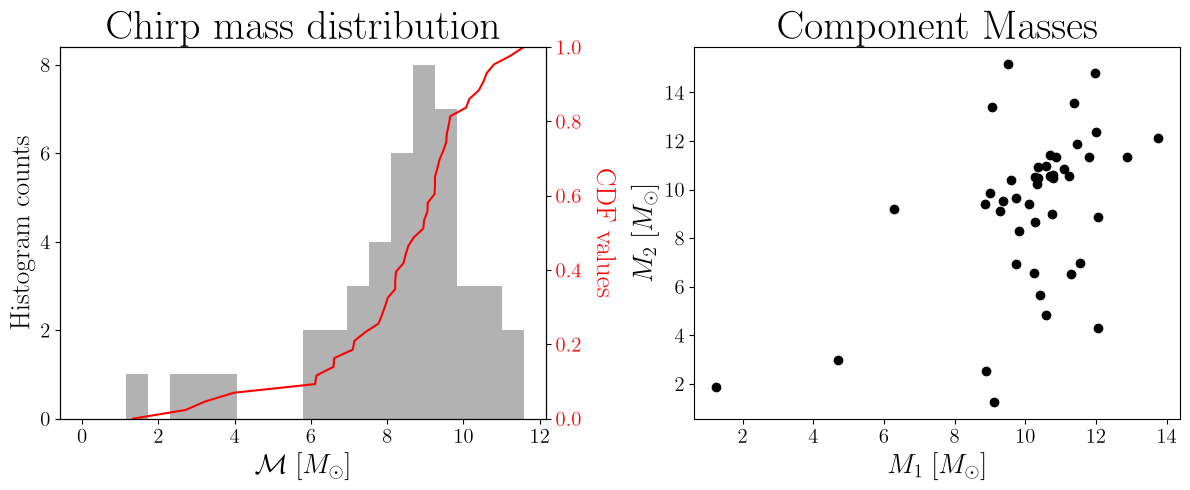

In [29]:
fig, axes = plt.subplots(ncols=2, figsize=(12,5))
fs_title = 30
fs_label= 20
fs_tick = 15
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": "Times New Roman",
})

# Histogram
ax = axes[0]
bins = np.linspace(0, max(m_chirp), 21) # use 20 bins, up to the maximum chirp mass
ax.hist(m_chirp, bins=bins, color='black', alpha=0.3)
ax.set_ylabel('Histogram counts', fontsize=fs_label)
ax.set_xlabel(r'$\mathcal{M} \; [M_\odot$]', fontsize=fs_label)
ax.set_title('Chirp mass distribution', fontsize=fs_title)
ax.tick_params(axis='both', which='major', labelsize=fs_tick)

# CDF
ax = ax.twinx()
cdf_x_values = np.sort(m_chirp)
cdf_y_values = np.cumsum(cdf_x_values)
cdf_y_values /= cdf_x_values[-1]
np.insert(cdf_x_values, 0, 0) # insert a 0 at the front of the array
cdf_y_values = np.linspace(0, ax.get_ylim()[1], len(cdf_x_values))
ax.plot(cdf_x_values, cdf_y_values, 'r')
ax.set_ylabel('CDF values', rotation=270, labelpad=25, fontsize=fs_label, color='red')
ax.set_ylim(0, 1)
ax.tick_params(axis='y', which='major', labelsize=fs_tick, labelcolor='red')
ax.grid(False)

# Scatter plot 
ax = axes[1]
ax.scatter(m1, m2, color='black')
ax.set_title('Component Masses', fontsize=fs_title)
ax.set_xlabel(r'$M_1 \; [M_\odot$]', fontsize=fs_label)
ax.set_ylabel(r'$M_2 \; [M_\odot$]', fontsize=fs_label)
ax.tick_params(axis='both', which='major', labelsize=fs_tick)

fig.tight_layout()